<a href="https://colab.research.google.com/github/madinayergeshbay-sudo/madina/blob/main/madina.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import json
import requests
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from io import BytesIO

In [2]:
def load_data_from_api():
    url = "https://ll.thespacedevs.com/2.0.0/launch/upcoming"

    os.makedirs("data", exist_ok=True)

    response = requests.get(url)
    print("상태 코드:", response.status_code)

    data = response.json()

    with open("data/launches.json", "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=4)

    df = pd.json_normalize(data["results"])
    print(df.head())

    return data, df

In [3]:
data, df = load_data_from_api()

상태 코드: 200
                                     id  \
0  2e3e33a1-b87d-4d52-a7e7-8cc5a28046fd   
1  1d24bfe7-d524-41f0-85de-09e967618710   
2  6f2868b8-1000-48e5-893b-700c1371b4fb   
3  d44f47c7-5e3e-40fb-9d10-b6e851acf81a   
4  f8766455-2b03-4629-a36e-b931c8b4a6c5   

                                                 url launch_library_id  \
0  https://ll.thespacedevs.com/2.0.0/launch/2e3e3...              None   
1  https://ll.thespacedevs.com/2.0.0/launch/1d24b...              None   
2  https://ll.thespacedevs.com/2.0.0/launch/6f286...              None   
3  https://ll.thespacedevs.com/2.0.0/launch/d44f4...              None   
4  https://ll.thespacedevs.com/2.0.0/launch/f8766...              None   

                                    slug  \
0      long-march-8a-satnet-leo-group-20   
1          long-march-2d-shiyan-30-03-04   
2  falcon-9-block-5-starlink-group-10-48   
3  falcon-9-block-5-starlink-group-17-31   
4          long-march-6a-unknown-payload   

                    

In [4]:
def get_pictures():
    os.makedirs("image", exist_ok=True)

    with open("data/launches.json", "r", encoding="utf-8") as f:
        launches = json.load(f)

    results = launches["results"]
    saved_files = []

    for i, launch in enumerate(results):
        image_url = launch.get("image")

        if image_url is None:
            print(f"{i+1}번째: 이미지 없음")
            continue

        try:
            response = requests.get(image_url, timeout=10)

            if response.status_code == 200:
                file_ext = image_url.split(".")[-1].split("?")[0]
                if len(file_ext) > 5:
                    file_ext = "jpg"

                file_name = f"image/rocket_{i+1}.{file_ext}"

                with open(file_name, "wb") as f:
                    f.write(response.content)

                saved_files.append(file_name)
                print(f"저장 완료: {file_name}")
            else:
                print(f"다운로드 실패: {image_url}")

        except Exception as e:
            print(f"오류 발생: {e}")

    return saved_files

In [5]:
saved_files = get_pictures()

저장 완료: image/rocket_1.jpeg
저장 완료: image/rocket_2.jpeg
저장 완료: image/rocket_3.png
저장 완료: image/rocket_4.png
저장 완료: image/rocket_5.jpeg
저장 완료: image/rocket_6.jpeg
저장 완료: image/rocket_7.png
저장 완료: image/rocket_8.png
저장 완료: image/rocket_9.png
저장 완료: image/rocket_10.jpeg


In [6]:
def show_images(image_folder="image", max_images=10):
    image_files = os.listdir(image_folder)
    image_files = image_files[:max_images]

    plt.figure(figsize=(15, 8))

    for i, img_name in enumerate(image_files):
        img_path = os.path.join(image_folder, img_name)
        img = Image.open(img_path)

        plt.subplot(2, 5, i + 1)
        plt.imshow(img)
        plt.title(img_name, fontsize=8)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

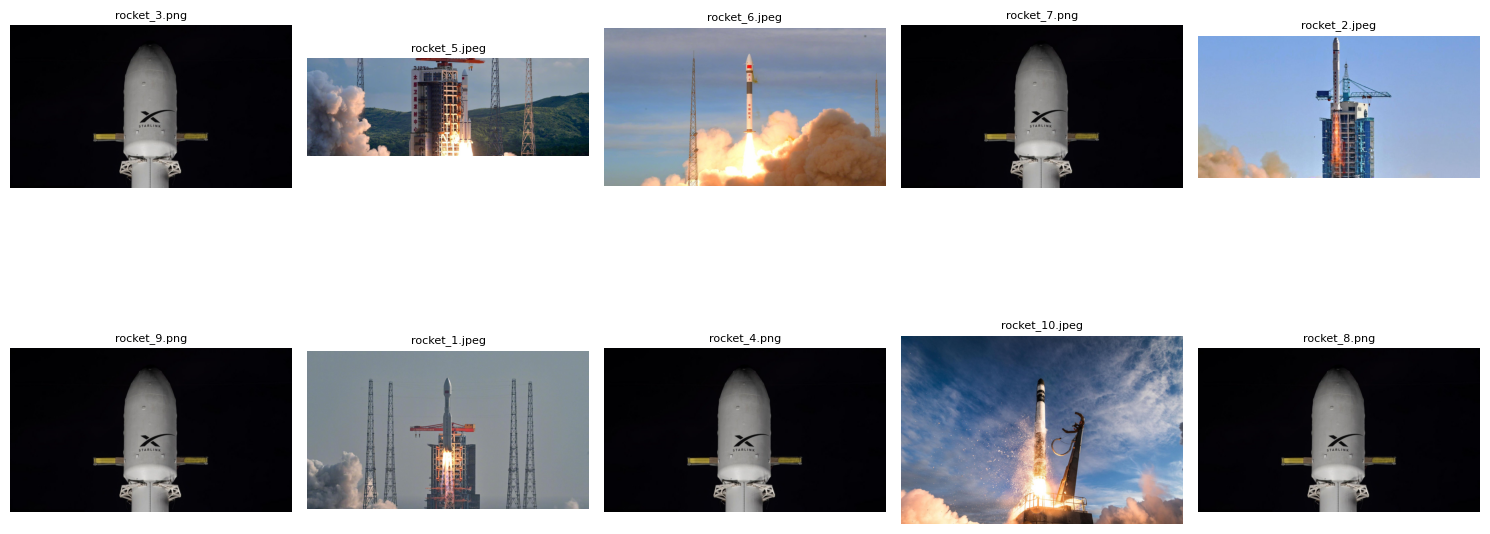

In [7]:
show_images()

In [8]:
titanic_url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic_df = pd.read_csv(titanic_url)

print(titanic_df.head())
print(titanic_df.info())
print(titanic_df.describe())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

In [9]:
print("결측값 개수:")
print(titanic_df.isnull().sum())

print("\n생존자 수:")
print(titanic_df["Survived"].value_counts())

print("\n성별 생존율:")
print(titanic_df.groupby("Sex")["Survived"].mean())

결측값 개수:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

생존자 수:
Survived
0    549
1    342
Name: count, dtype: int64

성별 생존율:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


In [10]:
from sklearn.datasets import load_iris

iris = load_iris()
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df["target"] = iris.target

print(iris_df.head())
print(iris_df.describe())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000  

In [11]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()
housing_df = pd.DataFrame(housing.data, columns=housing.feature_names)
housing_df["target"] = housing.target

print(housing_df.head())
print(housing_df.describe())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  target  
0    -122.23   4.526  
1    -122.22   3.585  
2    -122.24   3.521  
3    -122.25   3.413  
4    -122.25   3.422  
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%       

상태 코드: 200
                                     id  \
0  2e3e33a1-b87d-4d52-a7e7-8cc5a28046fd   
1  1d24bfe7-d524-41f0-85de-09e967618710   
2  6f2868b8-1000-48e5-893b-700c1371b4fb   
3  d44f47c7-5e3e-40fb-9d10-b6e851acf81a   
4  f8766455-2b03-4629-a36e-b931c8b4a6c5   

                                                 url launch_library_id  \
0  https://ll.thespacedevs.com/2.0.0/launch/2e3e3...              None   
1  https://ll.thespacedevs.com/2.0.0/launch/1d24b...              None   
2  https://ll.thespacedevs.com/2.0.0/launch/6f286...              None   
3  https://ll.thespacedevs.com/2.0.0/launch/d44f4...              None   
4  https://ll.thespacedevs.com/2.0.0/launch/f8766...              None   

                                    slug  \
0      long-march-8a-satnet-leo-group-20   
1          long-march-2d-shiyan-30-03-04   
2  falcon-9-block-5-starlink-group-10-48   
3  falcon-9-block-5-starlink-group-17-31   
4          long-march-6a-unknown-payload   

                    

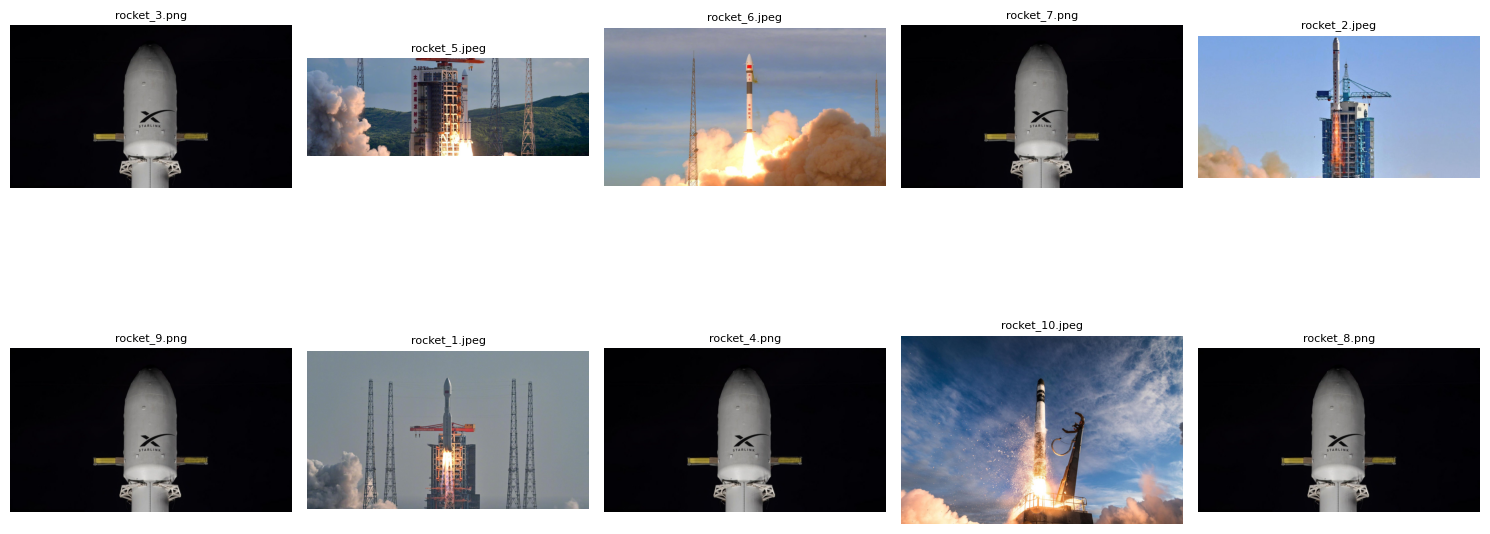

In [12]:
data, df = load_data_from_api()
saved_files = get_pictures()
show_images()

In [13]:
# Titanic
titanic_df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")
print(titanic_df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [14]:
# iris
from sklearn.datasets import load_iris
iris = load_iris()
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
print(iris_df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [15]:
# california housing
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
housing_df = pd.DataFrame(housing.data, columns=housing.feature_names)
print(housing_df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  


In [16]:
print(os.listdir("data"))
print(os.listdir("image")[:10])

['launches.json']
['rocket_3.png', 'rocket_5.jpeg', 'rocket_6.jpeg', 'rocket_7.png', 'rocket_2.jpeg', 'rocket_9.png', 'rocket_1.jpeg', 'rocket_4.png', 'rocket_10.jpeg', 'rocket_8.png']
